In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [3]:
# Define points and their classes in 2D space
x_points = np.array([-2, -1, 2, 1])
y_labels = np.array([0, 0, 1, 1])   # 0 for negative class, 1 for positive class

In [4]:
# Define values for theta and theta0
parameters = [
    (1, 0),
    (-1, 0),
    (0.5, 0),
    (5, 0)
]

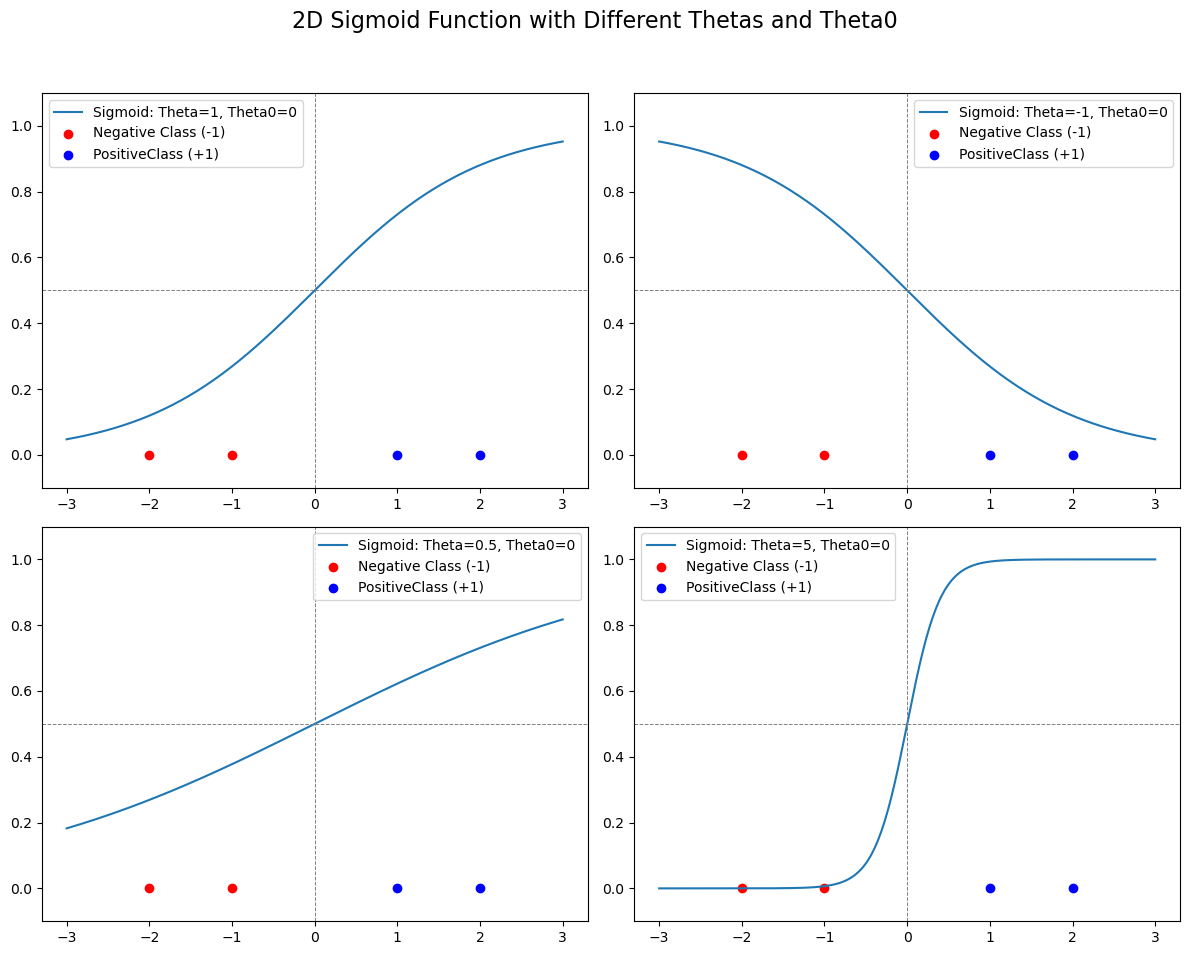

In [5]:
# Create a figure with 4 subpolots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (theta, theta0) in zip(axes.ravel(), parameters):
    # Compute the sigmoid for a range of X values
    x_range = np.linspace(-3, 3, 300)
    z = theta * x_range + theta0
    y = sigmoid(z)
    
    # Plot the sigmoid curve
    ax.plot(x_range, y, label=f'Sigmoid: Theta={theta}, Theta0={theta0}')
    
    # Plot the data points
    # ax.scatter(x_points[y_labels == 0], sigmoid(theta * x_points[y_labels == 0] + theta0), color='red', label='Negative Class (0)', zorder=5)
    # ax.scatter(x_points[y_labels == 1], sigmoid(theta * x_points[y_labels == 1] + theta0), color='blue', label='Positive Class (1)', zorder=5)
    ax.scatter(x_points[:2], x_points[:2] - x_points[:2], color='red', label='Negative Class (-1)')
    ax.scatter(x_points[2:], x_points[2:] - x_points[2:], color='blue', label='PositiveClass (+1)')
    
    # Formatting the plot
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.7) # Decision boundary at y=0.5
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.set_ylim(-0.1, 1.1)
    ax.legend()

# Set overall figure title
fig.suptitle('2D Sigmoid Function with Different Thetas and Theta0', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

#### For 3D visualization

In [6]:
import plotly.graph_objects as go

In [7]:
# Define positive and negative data points
positive_points = np.array([[2, 3],
                            [4, 5],
                            [3, 6],
                            [5, 4]])

negative_points = np.array([[-2, -3],
                            [-4, -5],
                            [-3, -6],
                            [-5, -4]])

In [ ]:
# Create a grid of 'x' and 'y' values
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)

# Define weights nd bias for the 2D classifier
w1, w2, b = 1, 1, 0 # These can be adjusted to see different decision boundaries as needed

# Compute 'z' as a linear combination of 'x' and 'y'
Z = w1 * X + w2 * Y + b

# Evaluate the sigmoid function on 'z'
S = sigmoid(Z)

# Create a trace for positive points on the XY plane
positive_trace = go.Scatter3d(
    x=positive_points[:, 0],
    y=positive_points[:, 1],
    z=np.full(positive_points.shape[0], 0),
    mode='markers',
    marker=dict(size=5, color='blue', opacity=0.8),
    name='Positive Points'
)

# Create trace for negative points on the XY plane
negative_trace = go.Scatter3d(
    x=negative_points[:, 0],
    y=negative_points[:, 1],
    z=np.full(negative_points.shape[0], 0),
    mode='markers',
    marker=dict(size=5, color='red', opacity=0.8),
    name='Negative Points'
)

# Create the surface trace for the sigmoid function
sigmoid_surface = go.Surface(
    x=X,
    y=Y,
    z=S,
    opacity=0.6,
    colorscale='Viridis',
    name='Sigmoid Surface',
    showscale=False
)

# Create trace for classifier boundary plane at z=0.5
boundary_plane = go.Scatter3d(
    x=X,
    y=Y,
    z=np.full_like(X, 0.5),
    mode='lines',
    line=dict(color='green', width=6),
    name='Classifier Boundary'
)

# Create figure object
fig = go.Figure(data=[positive_trace, negative_trace, sigmoid_surface, boundary_plane])

# Update layout to rotate the view
fig.update_layout(
    title='Interactive 3D Plot Visualization of 2D Sigmoid Classifier Boundary on the XY Plane',
    scene=dict(
        xaxis_title='X-axis',
        yaxis_title='Y-axis',
        zaxis_title='Sigmoid Output(z)',
        zaxis=dict(nticks=4, range=[0, 1]),
        camera=dict(up=dict(x=0, y=0, z=1), eye=dict(x=2, y=2, z=0.1)))
)